**Libraries**

In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

**Loading image and Labels**

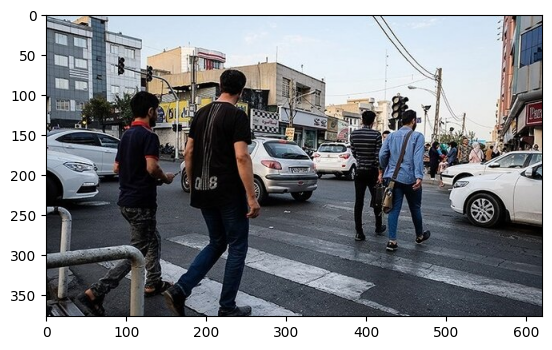

In [12]:
image = cv2.imread("pedestrian.jpg")
image_height, image_width, _ = image.shape

plt.imshow(image[...,::-1])

In [13]:
#Load labels from txt file (COCO labels)
with open('./model/tensorflow/object_detection_classes_coco.txt', 'r') as f:
    class_names = f.read().split('\n')
print(class_names[1])

bicycle


**Binary Large Object**

In [14]:
#Lets build a input's blob 
blob = cv2.dnn.blobFromImage(image, size=(300, 300), swapRB=True, crop=False)
blob.shape

(1, 3, 300, 300)

**Build our network using pre-trained model's weight**

In [15]:
#Read network weights and architecture for pre-trained models -> Single Shot Detector
model = cv2.dnn.readNetFromTensorflow('model/tensorflow/frozen_inference_graph.pb', 'model/tensorflow/ssd_mobilenet_v2_coco_2018_03_29.pbtxt')

#Introduce our input to the network
model.setInput(blob)

**Prediction in OpenCV using SSD-MobileNet**

person 92.6 %
person 81.75 %
person 69.67 %
person 61.7 %
traffic light 59.26 %
person 57.5 %
car 57.13 %
car 57.09 %
car 50.94 %
car 50.14 %
person 43.99 %
car 34.93 %
person 32.74 %
person 32.71 %
person 26.97 %
car 26.49 %


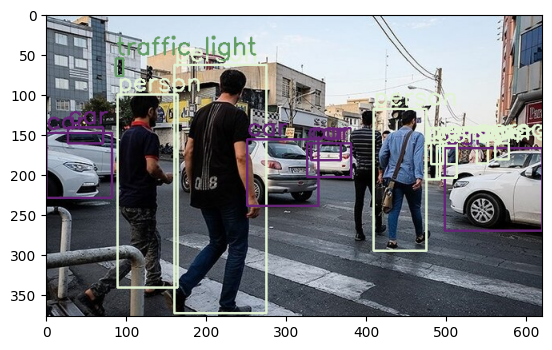

In [16]:
DETECTION_THRESHOLD = 0.25

#Run the detector over given blob of input image
output = model.forward()

#Get a different color array for each of the classes
colors = np.random.uniform(0, 255, size=(len(class_names), 3))

for detection in output[0,0,:,:]:

    #This is the accuracy estimated for this detection at sigmoid layer ...
    score = float(detection[2])

    if score > DETECTION_THRESHOLD: #check if estimated score is more that threshold, if so, we have a meaningful detection on our side
        
        #Find detected class name from coco syntexts 
        class_id = detection[1]
        class_name = class_names[int(class_id)-1]
        color = colors[int(class_id)]

        #Find the absolute coordinations of detected object
        left = detection[3] * image_width
        top = detection[4] * image_height
        right = detection[5] * image_width
        bottom = detection[6] * image_height
        
        #Drawing bounding boxes
        cv2.rectangle(image, (int(left), int(top)), (int(right), int(bottom)), color, thickness=2)
        cv2.putText(image, class_name, (int(left), int(top - 5)), cv2.FONT_HERSHEY_SIMPLEX, 1, color, 2)

        print(class_name, round(score*100,2),"%")

plt.imshow(image[...,::-1]);